In [1]:
#BallScrewKneeVectors_v1
#Code to compute knee torque when using a ball screw actuator with lever arm. 
#Vector analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from vectoroperations import rotate2d


In [2]:

# %%
O=np.array([0,0]) #Knee center
P0=np.array([0,0.10]) #Patella or lever arm middle position
P = rotate2d(P0, 90)   # anglein degrees
H_bscrew=0.10 # Height of ball screw above knee center.
Forceballscrew=500 #Force applied by ball screw in N

# Rotate2D(vector, angle in degrees CW +)
F = rotate2d(P, 170)*2   # foot vector

Pvert=np.array([P[0],H_bscrew]) # Vector from knee to vertical projection of P onto line of action of ball screw.
Pup=Pvert-P #Vector from P to Pvert 


In [3]:

# %% calculating point B (ball screw) using trianlge of B, P, and Pup

L_lever=np.linalg.norm(P-O) #Lever arm length
L_pushrod=0.2 #Pushrod length from ballscrew
L_Pup=np.linalg.norm(Pup) #Distance from P to Pup
L_pushrodmin=L_lever**2+H_bscrew**2 #Minimum pushrod length when P is at top of lever arm.

L_bscrew=np.sqrt(L_pushrod**2-L_Pup**2) #Distance from Pup to B (ball screw)

Bmag=np.array([-L_bscrew, 0]) #Ball screw vector
B=Bmag+Pvert #Ball screw position in global coordinates

print('P0:', P0)
print('P:', P)  
print('Pup:', Pup)
print('F:', F)
print('B:', B)
print('L_Pup:', L_Pup)
print('L_bscrew:', L_bscrew)
print('L_pushrodmin:', L_pushrodmin)



P0: [0.  0.1]
P: [-1.000000e-01  6.123234e-18]
Pup: [0.  0.1]
F: [ 0.19696155 -0.03472964]
B: [-0.27320508  0.1       ]
L_Pup: 0.1
L_bscrew: 0.17320508075688776
L_pushrodmin: 0.020000000000000004


In [4]:
# %% Torque calculations

Fpushrod = (P - B) / np.linalg.norm(P - B) * Forceballscrew
torque_O = np.cross(P, Fpushrod)


print('Torque at knee center O:', torque_O, "N.m")



Torque at knee center O: 24.999999999999996 N.m


C:\Users\smohamedthangal\AppData\Local\Temp\ipykernel_99400\900869516.py:4: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  torque_O = np.cross(P, Fpushrod)


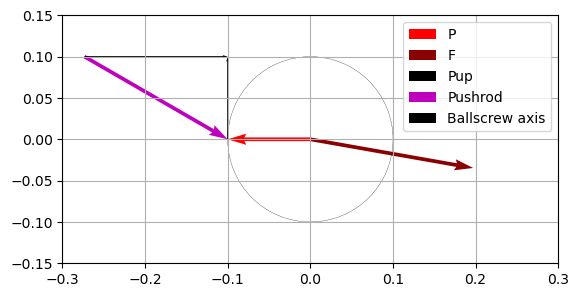

In [5]:
# %% Graphing
fig = plt.figure()
fig.canvas.manager.set_window_title('Ballscrewknee')
ax = plt.gca()

plt.quiver(O[0], O[1], P[0], P[1], angles='xy', scale_units='xy', scale=1, color='r', label='P')
plt.quiver(O[0], O[1], F[0], F[1], angles='xy', scale_units='xy', scale=1, color='darkred', label='F')
plt.quiver(P[0], P[1], Pup[0], Pup[1], angles='xy', scale_units='xy', scale=1, width=0.002, color='k', label='Pup')
plt.quiver(B[0], B[1], P[0]-B[0], P[1]-B[1], angles='xy', scale_units='xy', scale=1, color='m', label='Pushrod')
plt.quiver(B[0], B[1], Pvert[0]-B[0], Pvert[1]-B[1], angles='xy', scale_units='xy', scale=1,width=0.002, color='k', label='Ballscrew axis')


circle = patches.Circle((0, 0), radius=L_lever, edgecolor='black', facecolor='none', linewidth=0.2)
ax.add_patch(circle)

siz = 0.15
plt.xlim(-siz*2, siz*2)   # you often need to set limits manually —
plt.ylim(-siz, siz)   # quiver doesn't auto-scale the view the way plot() does
ax.set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
#plt.show()



# Use block in VSC to allow scrpit compeltion. not needed in Spyder. 
plt.show(block=False)
input("Press Enter to continue...")
plt.close('all')


# %%
